In [20]:
#data visualization
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
# import plotly.express as px
from matplotlib import pyplot
from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
# from statsmodels.graphics.tsaplots import plot_pacf

#graph theory
import networkx as nx
import numpy as np



#tqdm
from tqdm import tqdm

#for copy
import copy

#pd np
import pandas as pd
import numpy as np

#stat
import scipy.stats
import gc

# sensitivity analysis of k in k-fold cross-validation
from numpy import mean
from sklearn.datasets import make_classification
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
from sklearn.ensemble import RandomForestClassifier

In [21]:
# pip install gudhi

In [22]:
from typing import Tuple

import gudhi as gd  # type: ignore
import numpy as np
from scipy.linalg import eigh
from scipy.sparse import csgraph


In [23]:
# # pip install gudhi
# # Load the Drive helper and mount
# from google.colab import drive
# drive.mount('/content/drive')

In [24]:
#extended version
def compute_persistent_homology(graph, filtration):
    """
    Compute the persistent homology of a graph with a given filtration.

    :param graph: A networkx graph.
    :param filtration: A list of node filtration values, corresponding to each node in the graph.
    :return: Persistent homology of dimension one.
    """
    # Create simplex tree
    st = gd.SimplexTree()

    # Add vertices with filtration values
    for i, node in enumerate(graph.nodes):
        st.insert([node], filtration=filtration[i])

    # Add edges
    for edge in graph.edges:
        st.insert(list(edge), filtration=max(filtration[list(graph.nodes()).index(edge[0])], filtration[list(graph.nodes()).index(edge[1])]))
    # Expand to clique complex
    st.extend_filtration()

    persistence = st.extended_persistence(min_persistence=-1e10)
    tmp = []
    tmp.extend(persistence[0])
    tmp.extend(persistence[1])
    tmp.extend(persistence[2])
    tmp.extend(persistence[3])
    persistence = tmp

    #if birth > death change them
    tmp = []
    for gen in persistence:
        tmp.append((gen[0],(min(gen[1][0],gen[1][1]),max(gen[1][0],gen[1][1])) ))

    persistence = tmp

    #Filter for dimension one homology
    dim1_res = []
    for gen in persistence:
        if gen[0] == 1:
            dim1_res.append(gen)
    return dim1_res




## Reading Data

In [25]:
raw_data = pd.read_csv("rsif20150279supp4.txt", sep=" ")
G_conf = nx.Graph()

node_list = []
node_list.extend(list(raw_data['id1'].unique()))
node_list.extend(list(raw_data['id2'].unique()))
node_list = list(set(node_list))
n_nodes = len(node_list)

for row_index in tqdm(range(len(raw_data))):
    v1 = raw_data.iloc[row_index]['id1']
    v2 = raw_data.iloc[row_index]['id2']
    dur = raw_data.iloc[row_index]['duration']

    if not G_conf.has_edge(v1,v2):
        G_conf.add_weighted_edges_from([(v1,v2,1)])
    else:
        continue

100%|██████████| 71599/71599 [00:13<00:00, 5150.99it/s]


## Infection step:
 **Here, we implemented a step of infection, which means that each node $i$ with at least $th_i$ infected neighbours will be infected here.**


In [26]:
def do_transfers(Graph,list_inf,weight_normalizer=1,simple=True, th=2, betha = 0.5, q_complex=-1):
    #if this infection is simple
    if simple:
        new_infected_marker = False
        new_infected_nodes = []

        all_nodes = list(Graph.nodes)

        for i in all_nodes:
            if i in list_inf:
                continue

            else:
                edges = list(Graph.neighbors(i))
                n_infected_neighbours = 0
                for j in edges:
                    if j in list_inf:
                        n_infected_neighbours += 1

                pr_infection = 1-(1-betha)**n_infected_neighbours
                if np.random.uniform(0,1) <= pr_infection:
                    new_infected_marker = True
                    new_infected_nodes.append(i)

        for i in new_infected_nodes:
            list_inf.append(i)

        return new_infected_marker, list_inf

    #complex
    else:
        new_infected_marker = False
        new_infected_nodes = []

        all_nodes = list(Graph.nodes)
        for i in all_nodes:

            if i in list_inf:
                continue

            else:
                n_infected_neighbours = 0
                edges = list(Graph.neighbors(i))
                for j in edges:
                    if j in list_inf:
                        n_infected_neighbours += 1

                if n_infected_neighbours >= th:
                    new_infected_marker = True
                    new_infected_nodes.append(i)
                elif np.random.uniform(0,1) <= q_complex and n_infected_neighbours > 1:
                    new_infected_marker = True
                    new_infected_nodes.append(i)

        for i in new_infected_nodes:
            list_inf.append(i)

        return new_infected_marker, list_inf

In [27]:
betha_set = [0.1,0.2,0.3,0.4,0.5,0.6]
threshold_set = [2,3,4,5,6,7,8,9]
np.random.choice(threshold_set)

7

## Complex

In [28]:
def doing_comlpex_contagion(q_complex_input):
    #Complex Contagion

    #do we have new infection?
    new_infected_nodes = True

    #counter of infection steps
    tim_curr = 0

    #graph and init infected nodes
    G = copy.deepcopy(G_fixed)
    list_inf = copy.deepcopy(list_inf_copy)

    #Adj matrix
    A = nx.to_numpy_array(G)
    weight_normalizer = np.max(A)

    #list of nodes
    all_nodes_list = list(G.nodes)

    #when every nodes got infected (None if hasn’t infected yet)
    step_of_infection_per_node = [None for i in range(len(list(G.nodes)))]

    for nod_indx in list_inf:
        if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
            step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr

    threshold_this_iter = np.random.choice(threshold_set)

    #iterations of infection
    while new_infected_nodes and len(list_inf) != len(all_nodes_list):
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(G,list_inf,simple=False, th=threshold_this_iter,q_complex=q_complex_input)

        for nod_indx in list_inf:
            if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
                step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr



    G_subgraph_for_PH = G.subgraph(all_nodes_list[:])

    order_of_infection = np.array(step_of_infection_per_node[:],dtype=float)

    if all(v is np.nan for v in order_of_infection):
        order_of_infection = np.nan_to_num(order_of_infection,nan=1)
    else:
        order_of_infection = np.nan_to_num(order_of_infection,nan=np.nanmax(order_of_infection)+1)

    persistent_homology = compute_persistent_homology(G_subgraph_for_PH, order_of_infection)

    #PRL method
    # degrees = [val for (node, val) in G_subgraph_for_PH.degree()]
    # try:
    #     rho, p_value = scipy.stats.spearmanr(degrees, order_of_infection,nan_policy='omit')
    # except:
    #     rho = 0
    # complex_prl_indic.append(rho)

    life_set = []
    for gen in persistent_homology:
        life_set.append(gen[1][1] - gen[1][0])
    complex_list_EPH1.append(np.mean(life_set))




## Simple

In [29]:
def doing_simple_contagion():
    #simple Contagion

    #do we have new infection?
    new_infected_nodes = True

    #counter of infection steps
    tim_curr = 0

    #graph and init infected nodes
    G = copy.deepcopy(G_fixed)
    list_inf = copy.deepcopy(list_inf_copy)


    #list of nodes
    all_nodes_list = list(G.nodes)

    #when every nodes got infected (None if hasn’t infected yet)
    step_of_infection_per_node = [None for i in range(len(list(G.nodes)))]



    betha_this_iter = np.random.choice(betha_set)

    for nod_indx in list_inf:
            if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
                step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr

    #iterations of infection
    while new_infected_nodes and len(list_inf) != len(all_nodes_list):
        tim_curr += 1
        new_infected_nodes, list_inf = do_transfers(G,list_inf,simple=True, betha=betha_this_iter)
        for nod_indx in list_inf:
            if step_of_infection_per_node[all_nodes_list.index(nod_indx)] == None:
                step_of_infection_per_node[all_nodes_list.index(nod_indx)] = tim_curr


    G_subgraph_for_PH = G.subgraph(all_nodes_list[:])

    order_of_infection = np.array(step_of_infection_per_node[:],dtype=float)
    if all(v is np.nan for v in order_of_infection):
        order_of_infection = np.nan_to_num(order_of_infection,nan=1)
    else:
        order_of_infection = np.nan_to_num(order_of_infection,nan=np.nanmax(order_of_infection)+1)
    persistent_homology = compute_persistent_homology(G_subgraph_for_PH, order_of_infection)



    #PRL method
    # degrees = [val for (node, val) in G_subgraph_for_PH.degree()]
    # try:
    #     rho, p_value = scipy.stats.spearmanr(degrees, order_of_infection,nan_policy='omit')
    # except:
    #     rho = 0
    # simple_prl_indic.append(rho)


    life_set = []
    for gen in persistent_homology:
        life_set.append(gen[1][1] - gen[1][0])
    simple_list_EPH1.append(np.mean(life_set))



In [30]:
# retrieve the model to be evaluate
def get_model():
    model = LogisticRegression()
    model = RandomForestClassifier()
    return model

# evaluate the model using a given test condition
def evaluate_model(cv,X,y):
    # get the model
    model = get_model()
    # evaluate the model
    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    # return scores
    return scores

In [31]:
# import sklearn
# sklearn.metrics.SCORERS.keys()

In [ ]:
#different q
#[-1,0.01,0.02,0.03,0.04,0.05,0.08,0.11,0.14,0.17]
q_set = [0.03,0.04,0.05]
dist_diff_q = []

for q_this_iter in tqdm(q_set):
    gc.collect()
    #list for different statistics
    complex_list_EPH1 = []
    simple_list_EPH1 = []
    for iteration_indx in tqdm(range(400)):
        gc.collect()
        #initilize graph and infected nodes
        n = n_nodes
        n_subgraph = n_nodes
        G_fixed = G_conf

        list_inf = list(np.random.choice(list(G_conf.nodes),5,replace=False))



        #creating a copy of initial graph and its infected nodes
        G_copy = copy.deepcopy(G_fixed)
        list_inf_copy = copy.deepcopy(list_inf)

        #simple and complex contagion
        doing_comlpex_contagion(q_complex_input=q_this_iter)
        gc.collect()
        doing_simple_contagion()

    #classification
    simples_df = pd.DataFrame()
    #simple
    simples_df['EXP1'] = simple_list_EPH1
    simples_df['label'] = [0 for i in range(len(simples_df))]

    #complex
    complex_df = pd.DataFrame()
    complex_df['EXP1'] = complex_list_EPH1
    complex_df['label'] = [1 for i in range(len(complex_df))]

    #concat
    all_df = pd.concat([simples_df,complex_df])
    all_df = all_df.sample(len(all_df),random_state=0)
    all_df.fillna(0,inplace=True)

    X = all_df[['EXP1']]
    y = all_df['label']

    cv = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = evaluate_model(cv,X=X,y=y)


    print(np.mean(scores))
    dist_diff_q.append(scores)

 30%|███       | 121/400 [06:59<16:03,  3.46s/it]

In [ ]:
len(dist_diff_q)

5

In [ ]:
np.save('Jan16_dist_diff_q_with_mean_400itperq-of-lifetime_q=0.03,0.04,0.05.npy', np.array(dist_diff_q))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Re-defining the example data (as the code execution state was reset)
q_values = np.array([q_set[i] if i > 0 else 0 for i in range(len(q_set))])  # Replace with your actual q values
y_means = np.array([np.mean(list_) for list_ in dist_diff_q])   # Replace with the mean of y for each q
y_stds = np.array([np.std(list_) for list_ in dist_diff_q])  # Replace with the standard deviation for each q
sample_sizes = np.array([len(list_) for list_ in dist_diff_q])  # Replace with the sample size for each q

# Calculating the 90% confidence interval
ci = stats.norm.interval(0.90, loc=y_means, scale=y_stds / np.sqrt(sample_sizes))

# The error for the plot is the difference between the mean and the confidence interval bounds
y_errors = np.vstack([y_means - ci[0], ci[1] - y_means])

# Creating the plot
plt.figure(figsize=(10, 6))
plt.errorbar(q_values, y_means, yerr=y_errors, fmt='-o', ecolor='red', capsize=5)

# Adding title and labels
plt.title('Line Plot with 90% Confidence Interval Error Bars', fontsize=16)
plt.xlabel('q', fontsize=14)
plt.ylabel('roc_auc', fontsize=14)

# Show the plot
plt.show()


In [ ]:
all_q = []
all_dist = []

for i in range(len(q_set)):
    all_dist.extend(dist_diff_q[i])
    for j in range(len(dist_diff_q[i])):
        all_q.append(q_set[i])

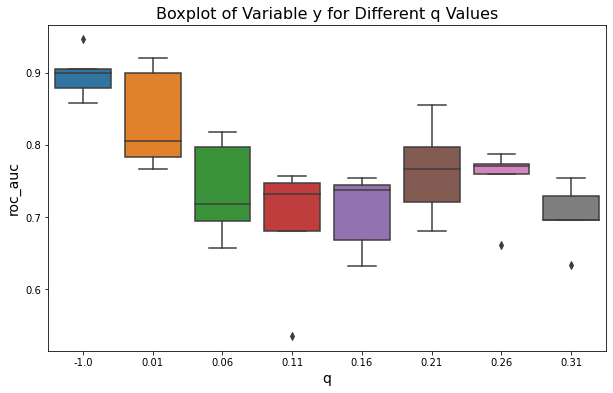

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Re-creating example data for the boxplot
data = {
    'q': all_q,  # Random q values
    'y': all_dist  # Random y values, normally distributed
}
df = pd.DataFrame(data)

# Creating a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='q', y='y', data=df)

# Adding titles and labels
plt.title('Boxplot of Variable y for Different q Values', fontsize=16)
plt.xlabel('q', fontsize=14)
plt.ylabel('roc_auc', fontsize=14)
# Show the plot
plt.show()


In [ ]:
1